   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (23.3 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: XAUUSD=X"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['XAUUSD=X']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: XAGUSD=X"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['XAGUSD=X']: YFTzMissingError('possibly delisted; no timezone found')


[데이터 로드 성공] 75개
[데이터 로드 실패] 2개 (티커/제공 제한일 수 있음) - 일부만 표시
 - ('구조분석', '금_현물(XAUUSD=X)', 'XAUUSD=X')
 - ('구조분석', '은_현물(XAGUSD=X)', 'XAGUSD=X')

[히트맵 최종 포함] 개수: 72
[월 표본 범위] 2006-02-28 ~ 2025-12-31


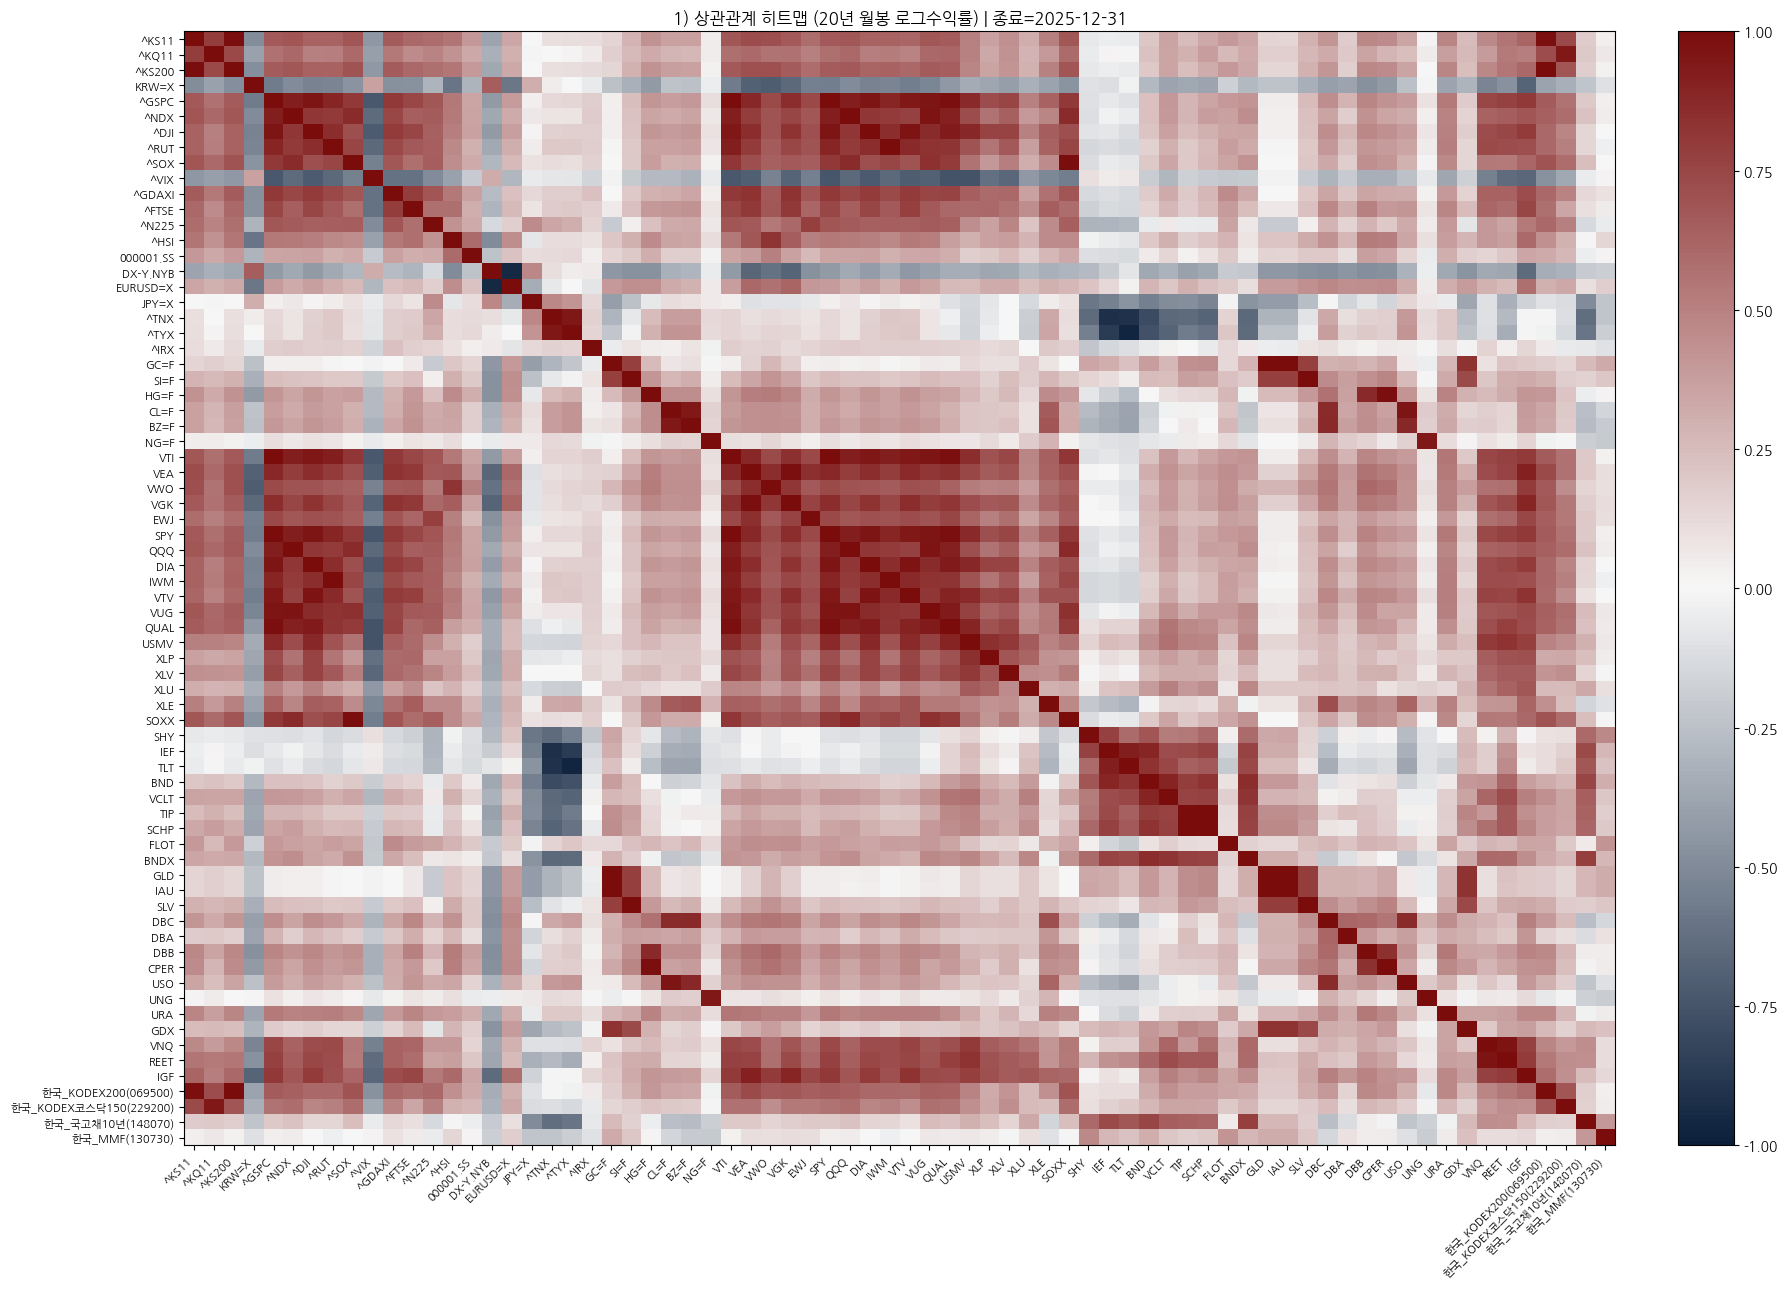

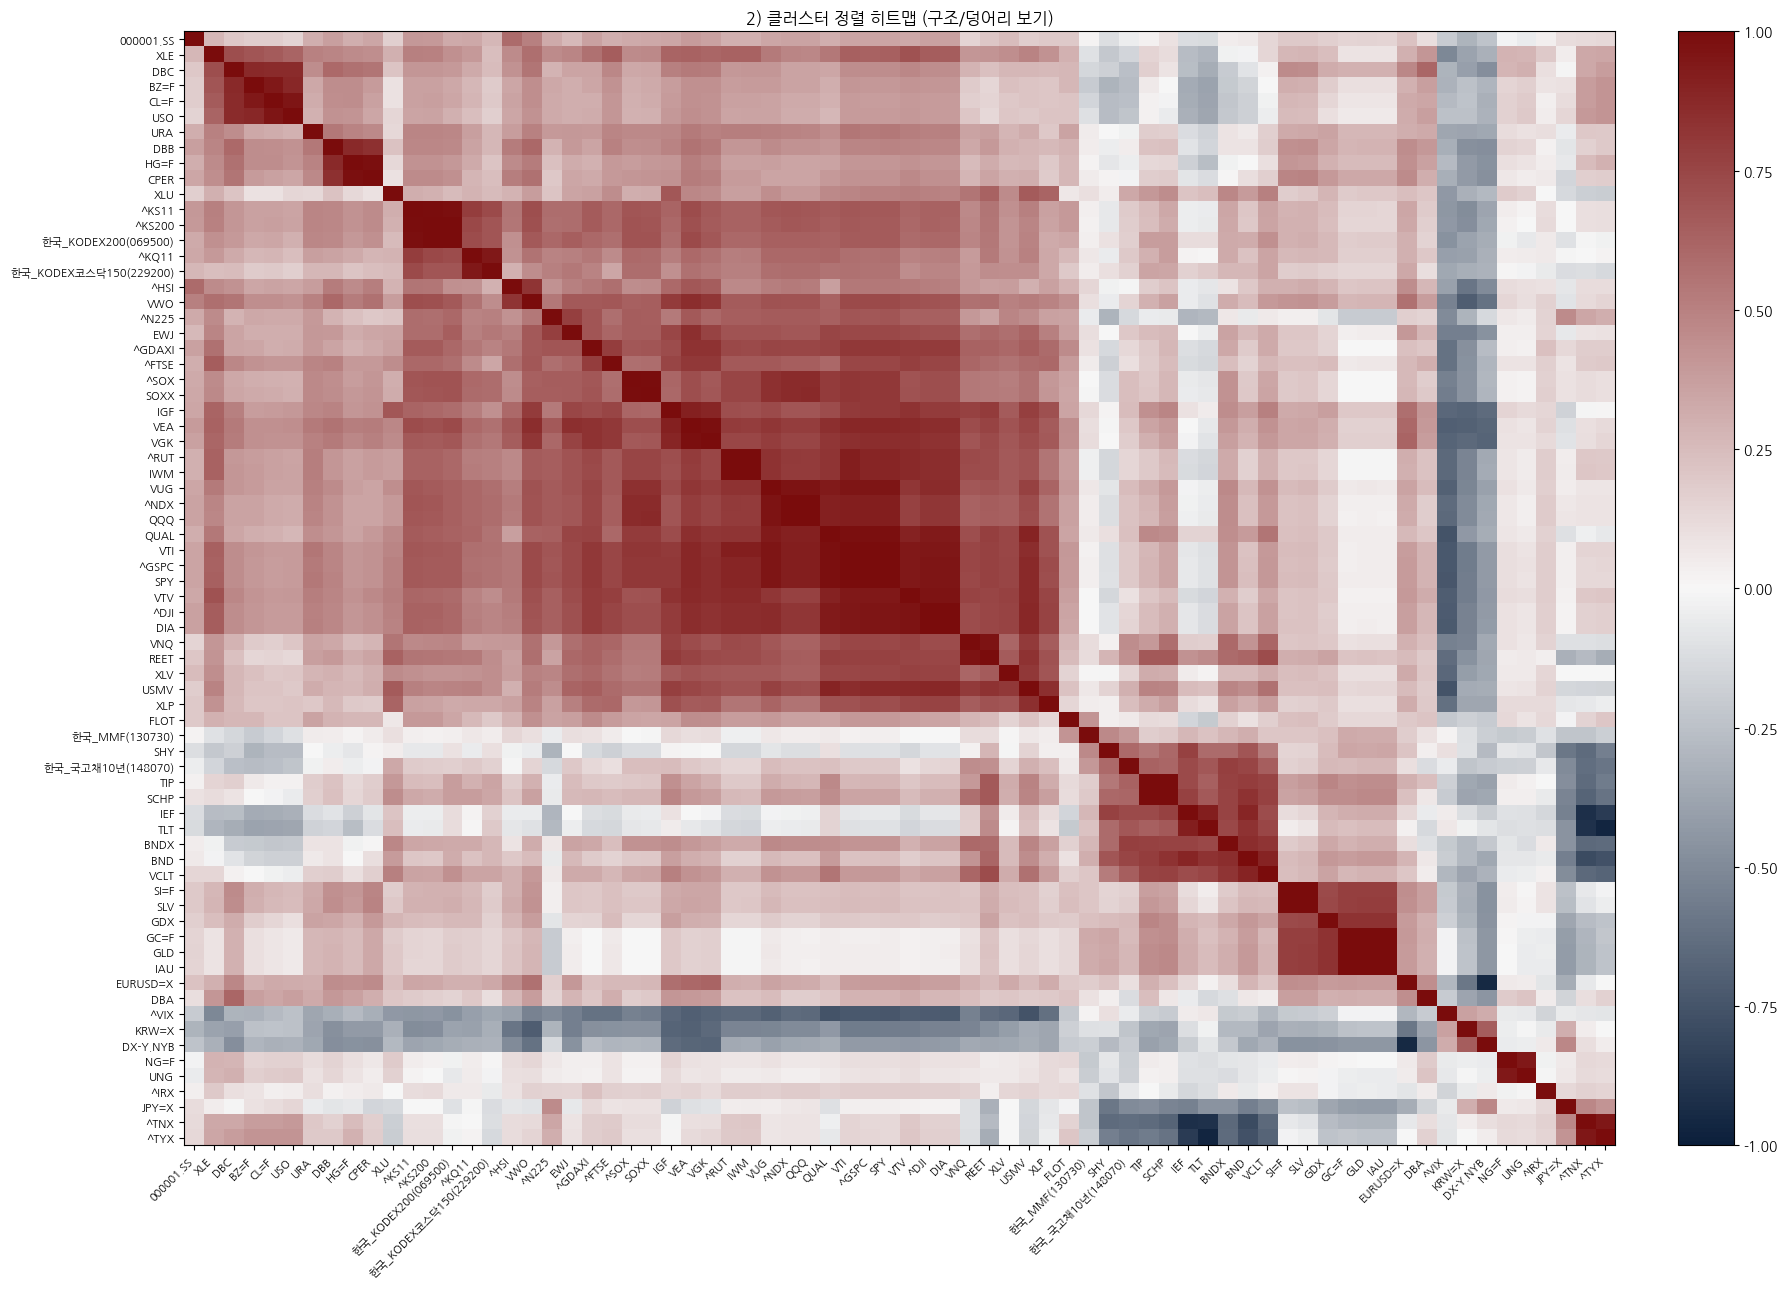


[주식 바스켓(기준)] ['한국_KODEX200(069500)']

[편입가능 TOP 20] (주식바스켓과 절대상관 낮은 순 + 덩어리 분산)


,순위,분류,역할,주식바스켓상관,주식바스켓절대상관,연환산수익,연환산변동성,클러스터,편입이유
한국_MMF(130730),1,채권/현금(방어),방어/분산(우수),0.032317,0.032317,0.019852,0.003431,3,채권/현금(방어): 주식과 상관이 매우 낮거나 반대(c=0.03) → 하락장 완충/...
한국_국고채10년(148070),2,기타,분산(양호),0.168105,0.168105,0.023702,0.055131,4,기타: 주식과 상관이 낮음(c=0.17) → 변동성/낙폭 완화에 도움 | 연환산 변...
한국_KODEX코스닥150(229200),3,기타,국면대응/중복주의,0.679868,0.679868,0.045048,0.251001,1,기타: 주식과 상관이 중간 이상(c=0.68) → 분산효과 제한(국면/테마 목적이면...



【분석 요약(한글)】
- 분석 기간(월봉): 2006-02-28 ~ 2025-12-31
- 히트맵 포함 자산 수: 72개
- 추천 TOP20: 편입가능 자산 후보군(ETF/ETN/국내ETF)에서만 선발

① 히트맵(클러스터 정렬)을 보면 자산이 '덩어리(비슷한 움직임)'로 묶입니다.
   → 같은 덩어리에서 여러 개를 많이 담으면 ‘중복투자’가 됩니다.
② TOP20은 '주식 바스켓'과의 절대상관이 낮은 자산을 우선 뽑아서
   → 포트폴리오 변동성/낙폭을 줄일 가능성이 높은 후보들입니다.
③ 동시에 클러스터별 1개씩 우선 선발하여(다양성)
   → 서로 다른 성격(축)을 최대한 확보하도록 구성했습니다.

【실무 결론】
- 기본 코어(주식): SPY/QQQ/VTI 등으로 시장 노출을 만든 뒤
- 방어/완충 축: 채권/현금 + 금(또는 일부 원자재) 조합이 구조적으로 유리한 경우가 많습니다.
- 원유/구리/우라늄/변동성(VXX/VXZ) 등은 변동이 커서
  ‘장기 고정 편입’보다 ‘국면 대응(비중 제한)’으로 쓰는 것이 실무적으로 안전합니다.


In [1]:
# =========================================================
# [Colab 올인원] 20년 월봉(로그수익률) 상관관계 히트맵 + (편입가능) TOP20 자동선정 + 이유(한글)
# - 대표지수(한국 포함) + (가능한) ETF/선물/현물지표 최대한 추가
# - 히트맵: 구조 분석(앵커/축/덩어리)용 → 지수/선물/현물지표도 포함
# - TOP20: 실제 편입 가능한 자산(ETF/ETN/국내 ETF) 후보군에서만 자동 선정
# - 기간: 2006-01-01 ~ 2025-12-31
# - 주기: 월봉(M, 월말)
# - 수익률: 로그수익률 log(Pt/Pt-1)
# - 실무형 색상(딥블루-화이트-딥레드) + 분석/결론 자동 프린트
# =========================================================

!pip -q install yfinance finance-datareader pandas numpy matplotlib scipy

# 한글 폰트 설치 및 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import FinanceDataReader as fdr

from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.spatial.distance import squareform
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.font_manager as fm # Import font_manager

# Matplotlib 폰트 설정 (한글 깨짐 방지)
# 폰트 경로 찾기 및 설정
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    fm.fontManager.addfont(font_file)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

# Rebuild font cache after installing new fonts
# fm._rebuild() # This line caused an AttributeError and is removed.

# -----------------------------
# 0) 설정
# -----------------------------
시작일 = "2006-01-01"
종료일 = "2025-12-31"

리샘플 = "M"               # ✅ 20년치 월봉(월말)
히트맵_최소개월 = 12 * 8     # 히트맵 포함 최소 데이터(8년)
상관_최소표본 = 36           # 상관계수 계산 최소 겹치는 표본(36개월)

이상치완화 = True            # 실무 권장(이상치 완화)
클립_하 = 0.01
클립_상 = 0.99

추천개수_TOP = 20            # 편입가능 TOP 20
클러스터_개수 = 10           # 다양성(덩어리 분산)용 클러스터 개수

# 실무형 Diverging 컬러맵(음수=딥블루 / 0=오프화이트 / 양수=딥레드)
실무_컬러맵 = LinearSegmentedColormap.from_list(
    "pro_div",
    ["#0B1F3B", "#F7F7F7", "#7A0C0C"],
    N=256
)

# -----------------------------
# 1) "구조 분석용(대표지수/지표)" + "편입가능(ETF/ETN/국내ETF)" 유니버스
# -----------------------------
구조분석_지수 = {
    # ===== 한국 대표지수 =====
    "한국_코스피(^KS11)": "^KS11",
    "한국_코스닥(^KQ11)": "^KQ11",
    "한국_코스피200(^KS200)": "^KS200",      # 안 되면 자동 제외될 수 있음
    "원달러환율(KRW=X)": "KRW=X",            # 가능 시

    # ===== 미국 대표지수 =====
    "미국_S&P500(^GSPC)": "^GSPC",
    "미국_나스닥100(^NDX)": "^NDX",
    "미국_다우(^DJI)": "^DJI",
    "미국_러셀2000(^RUT)": "^RUT",

    # ===== 섹터/산업 대표 =====
    "미국_필라델피아반도체(^SOX)": "^SOX",

    # ===== 변동성 지표 =====
    "변동성_VIX(^VIX)": "^VIX",

    # ===== 글로벌/지역 대표 =====
    "유럽_독일DAX(^GDAXI)": "^GDAXI",
    "영국_FTSE100(^FTSE)": "^FTSE",
    "일본_니케이225(^N225)": "^N225",
    "홍콩_항셍(^HSI)": "^HSI",
    "중국_상해종합(000001.SS)": "000001.SS",

    # ===== 달러/FX =====
    "달러인덱스(DX-Y.NYB)": "DX-Y.NYB",
    "유로달러(EURUSD=X)": "EURUSD=X",
    "달러엔(USDJPY)": "JPY=X",

    # ===== 금리(수익률 지표: 가격이 아니라 '수익률'이므로 해석 주의) =====
    "미국10년물금리(^TNX)": "^TNX",
    "미국30년물금리(^TYX)": "^TYX",
    "미국13주금리(^IRX)": "^IRX",

    # ===== 원자재(대표 선물/현물지표) =====
    "금_선물(GC=F)": "GC=F",
    "은_선물(SI=F)": "SI=F",
    "구리_선물(HG=F)": "HG=F",
    "원유_WTI선물(CL=F)": "CL=F",
    "원유_브렌트선물(BZ=F)": "BZ=F",
    "천연가스_선물(NG=F)": "NG=F",
    "금_현물(XAUUSD=X)": "XAUUSD=X",
    "은_현물(XAGUSD=X)": "XAGUSD=X",
}

# ✅ 편입가능 후보(미국 ETF/ETN)
편입가능_미국 = {
    # --- 글로벌/지역 분산(요청 반영) ---
    "미국전체_VTI": "VTI",
    "선진국_VEA": "VEA",
    "신흥국_VWO": "VWO",
    "유럽_VGK": "VGK",
    "일본_EWJ": "EWJ",

    # --- 주식(코어/성장/가치/방어) ---
    "미국_S&P500_SPY": "SPY",
    "미국_나스닥100_QQQ": "QQQ",
    "미국_다우_DIA": "DIA",
    "미국_러셀2000_IWM": "IWM",
    "가치주_VTV": "VTV",
    "성장주_VUG": "VUG",
    "퀄리티_QUAL": "QUAL",
    "저변동성_USMV": "USMV",

    # --- 섹터(방어/국면) ---
    "필수소비재_XLP": "XLP",
    "헬스케어_XLV": "XLV",
    "유틸리티_XLU": "XLU",
    "에너지_XLE": "XLE",

    # --- 반도체 ---
    "반도체_SOXX": "SOXX",

    # --- 채권 확장(요청 반영) ---
    "초단기국채_SHY": "SHY",
    "중기국채_IEF": "IEF",
    "장기국채_TLT": "TLT",
    "미국종합채권_BND": "BND",
    "장기회사채_VCLT": "VCLT",
    "물가연동채권_TIP": "TIP",
    "물가연동_SCHP": "SCHP",
    "변동금리채_FLOT": "FLOT",
    "글로벌채권_BNDX": "BNDX",

    # --- 원자재 세분화(요청 반영) ---
    "금_GLD": "GLD",
    "금_IAU": "IAU",
    "은_SLV": "SLV",
    "원자재종합_DBC": "DBC",
    "농산물_DBA": "DBA",
    "산업금속_DBB": "DBB",
    "구리_CPER": "CPER",
    "원유_USO": "USO",
    "천연가스_UNG": "UNG",
    "우라늄_URA": "URA",
    "금광주_GDX": "GDX",

    # --- 리츠/대체(요청 반영) ---
    "미국리츠_VNQ": "VNQ",
    "글로벌리츠_REET": "REET",
    "인프라_IGF": "IGF",

    # --- 변동성(주의: 장기보유 비추천 성격) ---
    "변동성_VXX": "VXX",
    "변동성_VXZ": "VXZ",
}

# ✅ 편입가능 후보(한국 ETF: FinanceDataReader)
편입가능_한국 = {
    "한국_KODEX200(069500)": ("FDR", "069500"),
    "한국_KODEX코스닥150(229200)": ("FDR", "229200"),
    "한국_국고채10년(148070)": ("FDR", "148070"),
    "한국_MMF(130730)": ("FDR", "130730"),
    "한국_금현물(411060)": ("FDR", "411060"),
}

# -----------------------------
# 2) 데이터 로더
# -----------------------------
def 야후_종가(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if df is None or len(df) == 0 or "Close" not in df.columns:
        return None
    s = df["Close"].dropna()
    return None if s.empty else s

def fdr_종가(code, start, end):
    try:
        df = fdr.DataReader(code, start, end)
        if df is None or len(df) == 0 or "Close" not in df.columns:
            return None
        s = df["Close"].dropna()
        return None if s.empty else s
    except:
        return None

# -----------------------------
# 3) 패널 생성(구조 분석용 + 편입가능)
# -----------------------------
def 패널_생성():
    series = []
    실패 = []

    # 구조 분석용(지수/선물/현물지표): Yahoo
    for 이름, 티커 in 구조분석_지수.items():
        s = 야후_종가(티커, 시작일, 종료일)
        if s is None:
            실패.append(("구조분석", 이름, 티커))
            continue
        s.name = 이름
        series.append(s)

    # 편입가능(미국 ETF/ETN): Yahoo
    for 이름, 티커 in 편입가능_미국.items():
        s = 야후_종가(티커, 시작일, 종료일)
        if s is None:
            실패.append(("편입가능_미국", 이름, 티커))
            continue
        s.name = 이름
        series.append(s)

    # 편입가능(한국 ETF): FDR
    for 이름, spec in 편입가능_한국.items():
        _, code = spec
        s = fdr_종가(code, 시작일, 종료일)
        if s is None:
            실패.append(("편입가능_한국", 이름, code))
            continue
        s.name = 이름
        series.append(s)

    가격 = pd.concat(series, axis=1).sort_index()
    return 가격, 실패

가격, 실패 = 패널_생성()

print(f"[데이터 로드 성공] {가격.shape[1]}개")
if 실패:
    print(f"[데이터 로드 실패] {len(실패)}개 (티커/제공 제한일 수 있음) - 일부만 표시")
    for x in 실패[:15]:
        print(" -", x)

# -----------------------------
# 4) 월봉 리샘플 + 로그수익률
# -----------------------------
월봉가격 = 가격.resample(리샘플).last()
로그수익률 = np.log(월봉가격 / 월봉가격.shift(1))

# 히트맵은 너무 짧은 시계열 제외(구조 분석 목적)
유효 = 로그수익률.count()[로그수익률.count() >= 히트맵_최소개월].index
로그수익률_히트맵 = 로그수익률[유효].dropna(how="all")

# 이상치 완화(실무)
if 이상치완화:
    lo = 로그수익률_히트맵.quantile(클립_하)
    hi = 로그수익률_히트맵.quantile(클립_상)
    로그수익률_히트맵 = 로그수익률_히트맵.clip(lower=lo, upper=hi, axis=1)

상관 = 로그수익률_히트맵.corr(min_periods=상관_최소표본)

print("\n[히트맵 최종 포함] 개수:", 상관.shape[0])
print("[월 표본 범위]", 로그수익률_히트맵.index.min().date(), "~", 로그수익률_히트맵.index.max().date())

# -----------------------------
# 5) 히트맵(실무 색상 + 클러스터 정렬)
# -----------------------------
def 히트맵_그리기(corr_df, 제목):
    plt.figure(figsize=(18, 13))
    ax = plt.gca()
    im = ax.imshow(corr_df.values, vmin=-1, vmax=1, cmap=실무_컬러맵, aspect="auto")

    ax.set_xticks(np.arange(len(corr_df.columns)))
    ax.set_yticks(np.arange(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(corr_df.index, fontsize=8)

    plt.title(제목)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

히트맵_그리기(상관, "1) 상관관계 히트맵 (20년 월봉 로그수익률) | 종료=2025-12-31")

거리 = ((1 - 상관) / 2).clip(0, 1)
압축거리 = squareform(거리.values, checks=False)
Z = linkage(압축거리, method="average")
정렬순서 = leaves_list(Z)
상관_정렬 = 상관.iloc[정렬순서, 정렬순서]
히트맵_그리기(상관_정렬, "2) 클러스터 정렬 히트맵 (구조/덩어리 보기)")

# -----------------------------
# 6) 편입가능 TOP20 자동선정 + 이유(한글)
# -----------------------------
def 편입가능인가(이름):
    return 이름.startswith("미국_") or 이름.startswith("한국_") or 이름 in list(편입가능_미국.keys())

# ✅ 주식바스켓(기준): 미국+한국 대표를 섞어서 “주식 전체”를 대표
주식기준_후보 = [
    "미국_S&P500_SPY",
    "미국_나스닥100_QQQ",
    "한국_KODEX200(069500)",
    "한국_코스피(^KS11)",
    "미국전체_VTI",
]
주식기준 = [x for x in 주식기준_후보 if x in 상관.columns]
if len(주식기준) == 0:
    주식기준 = list(상관.columns[:2])

# 편입가능 후보(실제로 히트맵에 들어온 것만)
편입후보 = [c for c in 상관.columns if c in 로그수익률_히트맵.columns and c in list(편입가능_미국.keys()) + list(편입가능_한국.keys())]
편입후보 = list(dict.fromkeys(편입후보))  # 중복 제거

# 연환산(월수익률 기준): 평균*12, 변동성*sqrt(12)
연환산수익 = 로그수익률_히트맵[편입후보].mean() * 12
연환산변동 = 로그수익률_히트맵[편입후보].std() * np.sqrt(12)

주식대비상관 = 상관.loc[편입후보, 주식기준].mean(axis=1)
주식대비절대상관 = 주식대비상관.abs()

# 클러스터 라벨(덩어리 분산)
클러스터 = pd.Series(fcluster(Z, 클러스터_개수, criterion="maxclust"), index=상관.index)
클러스터_편입 = 클러스터.reindex(편입후보)

추천테이블 = pd.DataFrame({
    "주식바스켓상관": 주식대비상관,
    "주식바스켓절대상관": 주식대비절대상관,
    "연환산수익": 연환산수익,
    "연환산변동성": 연환산변동,
    "클러스터": 클러스터_편입
}).dropna()

# 기준자산이 후보에 섞였으면 추천에서 제외
추천테이블 = 추천테이블.drop(index=[x for x in 주식기준 if x in 추천테이블.index], errors="ignore")

# 클러스터별 1개씩(다양성) + 나머지 채우기
첫선발 = (추천테이블.sort_values(["주식바스켓절대상관", "연환산변동성"], ascending=[True, True])
           .groupby("클러스터", as_index=False).head(1))
나머지 = 추천테이블.drop(index=첫선발.index, errors="ignore").sort_values(["주식바스켓절대상관", "연환산변동성"], ascending=[True, True])
TOP = pd.concat([첫선발, 나머지], axis=0).head(추천개수_TOP).copy()

def 자산분류(이름):
    u = 이름.upper()
    if "VXX" in u or "VXZ" in u:
        return "변동성(단기헤지)"
    if "GLD" in u or "IAU" in u or "금현물" in 이름:
        return "금(완충/헤지)"
    if "SLV" in u:
        return "은(원자재/고변동)"
    if "CPER" in u or "DBB" in u:
        return "산업금속/구리(경기민감)"
    if "USO" in u or "XLE" in u:
        return "에너지/원유(인플레/국면)"
    if "UNG" in u:
        return "천연가스(고변동)"
    if "DBC" in u or "DBA" in u:
        return "원자재(종합/농산물)"
    if any(x in u for x in ["TLT","IEF","SHY","BND","VCLT","TIP","SCHP","FLOT","BNDX","KTB","MMF"]):
        return "채권/현금(방어)"
    if any(x in u for x in ["VNQ","REET","IGF"]):
        return "리츠/인프라(실물자산)"
    if any(x in u for x in ["USMV","QUAL","XLP","XLV","XLU","VTV"]):
        return "방어형 주식"
    if any(x in u for x in ["SPY","QQQ","DIA","IWM","VUG","SOXX","VTI","VEA","VWO","VGK","EWJ"]):
        return "주식(지역/성장/섹터)"
    return "기타"

def 이유생성(row, 이름):
    c = row["주식바스켓상관"]
    v = row["연환산변동성"]
    r = row["연환산수익"]
    tag = 자산분류(이름)

    if c <= 0.15:
        역할 = "방어/분산(우수)"
        이유 = f"{tag}: 주식과 상관이 매우 낮거나 반대(c={c:.2f}) → 하락장 완충/분산에 유리"
    elif c <= 0.35:
        역할 = "분산(양호)"
        이유 = f"{tag}: 주식과 상관이 낮음(c={c:.2f}) → 변동성/낙폭 완화에 도움"
    else:
        역할 = "국면대응/중복주의"
        이유 = f"{tag}: 주식과 상관이 중간 이상(c={c:.2f}) → 분산효과 제한(국면/테마 목적이면 가능)"

    이유 += f" | 연환산 변동성≈{v:.2f}, 연환산 수익≈{r:.2f}"
    return 역할, 이유

역할들, 이유들, 분류들 = [], [], []
for 이름, row in TOP.iterrows():
    분류 = 자산분류(이름)
    역할, 이유 = 이유생성(row, 이름)
    분류들.append(분류)
    역할들.append(역할)
    이유들.append(이유)

TOP["분류"] = 분류들
TOP["역할"] = 역할들
TOP["편입이유"] = 이유들
TOP = TOP.sort_values(["주식바스켓절대상관", "연환산변동성"], ascending=[True, True]).copy()
TOP.insert(0, "순위", range(1, len(TOP) + 1))

print("\n[주식 바스켓(기준)]", 주식기준)
print("\n[편입가능 TOP 20] (주식바스켓과 절대상관 낮은 순 + 덩어리 분산)")
display(TOP[["순위","분류","역할","주식바스켓상관","주식바스켓절대상관","연환산수익","연환산변동성","클러스터","편입이유"]])

# -----------------------------
# 7) 결과 분석/결론 프린트(한글)
# -----------------------------
print("\n" + "="*70)
print("【분석 요약(한글)】")
print("="*70)
print(f"- 분석 기간(월봉): {로그수익률_히트맵.index.min().date()} ~ {로그수익률_히트맵.index.max().date()}")
print(f"- 히트맵 포함 자산 수: {상관.shape[0]}개")
print(f"- 추천 TOP{추천개수_TOP}: 편입가능 자산 후보군(ETF/ETN/국내ETF)에서만 선발")
print()
print("① 히트맵(클러스터 정렬)을 보면 자산이 '덩어리(비슷한 움직임)'로 묶입니다.")
print("   → 같은 덩어리에서 여러 개를 많이 담으면 ‘중복투자’가 됩니다.")
print("② TOP20은 '주식 바스켓'과의 절대상관이 낮은 자산을 우선 뽑아서")
print("   → 포트폴리오 변동성/낙폭을 줄일 가능성이 높은 후보들입니다.")
print("③ 동시에 클러스터별 1개씩 우선 선발하여(다양성)")
print("   → 서로 다른 성격(축)을 최대한 확보하도록 구성했습니다.")
print()
print("【실무 결론】")
print("- 기본 코어(주식): SPY/QQQ/VTI 등으로 시장 노출을 만든 뒤")
print("- 방어/완충 축: 채권/현금 + 금(또는 일부 원자재) 조합이 구조적으로 유리한 경우가 많습니다.")
print("- 원유/구리/우라늄/변동성(VXX/VXZ) 등은 변동이 커서")
print("  ‘장기 고정 편입’보다 ‘국면 대응(비중 제한)’으로 쓰는 것이 실무적으로 안전합니다.")

In [2]:
# =========================================================
# [엑셀 저장] TOP20 + 이유/사유 분리 + 상관행렬(히트맵 원본)까지 저장
# - TOP20: 요약/수치
# - 이유_사유: 문장만 따로(발표/보고서용)
# - 상관행렬: 히트맵 원본 데이터
# =========================================================

!pip -q install openpyxl

from google.colab import files
from datetime import datetime

# 1) 저장할 데이터프레임 준비
# - TOP: 네 코드에서 이미 만든 TOP DataFrame (순위/분류/역할/편입이유 포함)
# - 상관: 네 코드에서 만든 상관 DataFrame

# (A) TOP20 요약 시트: 숫자 중심(보기 좋게 컬럼 선택)
top20_요약 = TOP[[
    "순위",
    "분류",
    "역할",
    "주식바스켓상관",
    "주식바스켓절대상관",
    "연환산수익",
    "연환산변동성",
    "클러스터"
]].copy()

# (B) 이유/사유 시트: 문장만 따로(보고서/설명용)
이유_사유 = TOP[[
    "순위",
    "분류",
    "역할",
    "편입이유"
]].copy()

# (C) 상관행렬 시트(히트맵 원본)
상관행렬 = 상관.copy()

# 2) 파일명(날짜 포함)
ts = datetime.now().strftime("%Y%m%d_%H%M")
파일명 = f"20년월봉_상관히트맵_TOP20_추천결과_{ts}.xlsx"

# 3) 엑셀 저장(여러 시트)
with pd.ExcelWriter(파일명, engine="openpyxl") as writer:
    top20_요약.to_excel(writer, sheet_name="TOP20_요약", index=False)
    이유_사유.to_excel(writer, sheet_name="이유_사유(문장)", index=False)
    상관행렬.to_excel(writer, sheet_name="상관행렬(히트맵원본)", index=True)

print("✅ 엑셀 저장 완료:", 파일명)

# 4) (선택) Colab에서 바로 다운로드
files.download(파일명)


✅ 엑셀 저장 완료: 20년월봉_상관히트맵_TOP20_추천결과_20260116_1158.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# =========================================================
# [확실한 엑셀 저장 블록] TOP20이 "실제로 존재하는지" 확인 후 저장
# - TOP DataFrame(순위/편입이유 포함)이 있어야 저장됩니다.
# =========================================================

!pip -q install openpyxl

import os
from datetime import datetime

# 0) TOP 변수가 있는지 / 비어있지 않은지 체크
if "TOP" not in globals():
    raise NameError("TOP 변수가 없습니다. (TOP20을 만든 다음에 이 저장 코드를 실행해야 합니다.)")

if TOP is None or len(TOP) == 0:
    raise ValueError("TOP 데이터가 비어있습니다. (추천 TOP20 생성 결과가 0개로 나온 상태입니다.)")

print("✅ TOP20 생성 확인")
print(" - TOP 행 개수:", len(TOP))
print(" - TOP 컬럼:", list(TOP.columns))
display(TOP.head(5))

# 1) 저장할 시트 구성
# (A) TOP20 요약(숫자/지표 위주)
필수컬럼_요약 = ["순위","분류","역할","주식바스켓상관","주식바스켓절대상관","연환산수익","연환산변동성","클러스터"]
존재_요약 = [c for c in 필수컬럼_요약 if c in TOP.columns]
top20_요약 = TOP[존재_요약].copy()

# (B) 이유/사유(문장만 따로)
필수컬럼_이유 = ["순위","분류","역할","편입이유"]
존재_이유 = [c for c in 필수컬럼_이유 if c in TOP.columns]
이유_사유 = TOP[존재_이유].copy()

# (C) 상관행렬(히트맵 원본)도 같이 저장하고 싶으면 상관 변수가 있어야 함
상관행렬 = None
if "상관" in globals() and 상관 is not None and getattr(상관, "shape", (0,0))[0] > 0:
    상관행렬 = 상관.copy()

# 2) 파일명
ts = datetime.now().strftime("%Y%m%d_%H%M")
파일명 = f"TOP20_추천결과_이유분리_{ts}.xlsx"

# 3) 엑셀 저장
with pd.ExcelWriter(파일명, engine="openpyxl") as writer:
    top20_요약.to_excel(writer, sheet_name="TOP20_요약", index=False)
    이유_사유.to_excel(writer, sheet_name="이유_사유(문장)", index=False)
    if 상관행렬 is not None:
        상관행렬.to_excel(writer, sheet_name="상관행렬(히트맵원본)", index=True)

print("✅ 엑셀 저장 완료:", 파일명)
print("✅ 파일 존재 확인:", os.path.exists(파일명))


✅ TOP20 생성 확인
 - TOP 행 개수: 3
 - TOP 컬럼: ['순위', '주식바스켓상관', '주식바스켓절대상관', '연환산수익', '연환산변동성', '클러스터', '분류', '역할', '편입이유']


,순위,주식바스켓상관,주식바스켓절대상관,연환산수익,연환산변동성,클러스터,분류,역할,편입이유
한국_MMF(130730),1,0.032317,0.032317,0.019852,0.003431,3,채권/현금(방어),방어/분산(우수),채권/현금(방어): 주식과 상관이 매우 낮거나 반대(c=0.03) → 하락장 완충/...
한국_국고채10년(148070),2,0.168105,0.168105,0.023702,0.055131,4,기타,분산(양호),기타: 주식과 상관이 낮음(c=0.17) → 변동성/낙폭 완화에 도움 | 연환산 변...
한국_KODEX코스닥150(229200),3,0.679868,0.679868,0.045048,0.251001,1,기타,국면대응/중복주의,기타: 주식과 상관이 중간 이상(c=0.68) → 분산효과 제한(국면/테마 목적이면...


✅ 엑셀 저장 완료: TOP20_추천결과_이유분리_20260116_1158.xlsx
✅ 파일 존재 확인: True


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

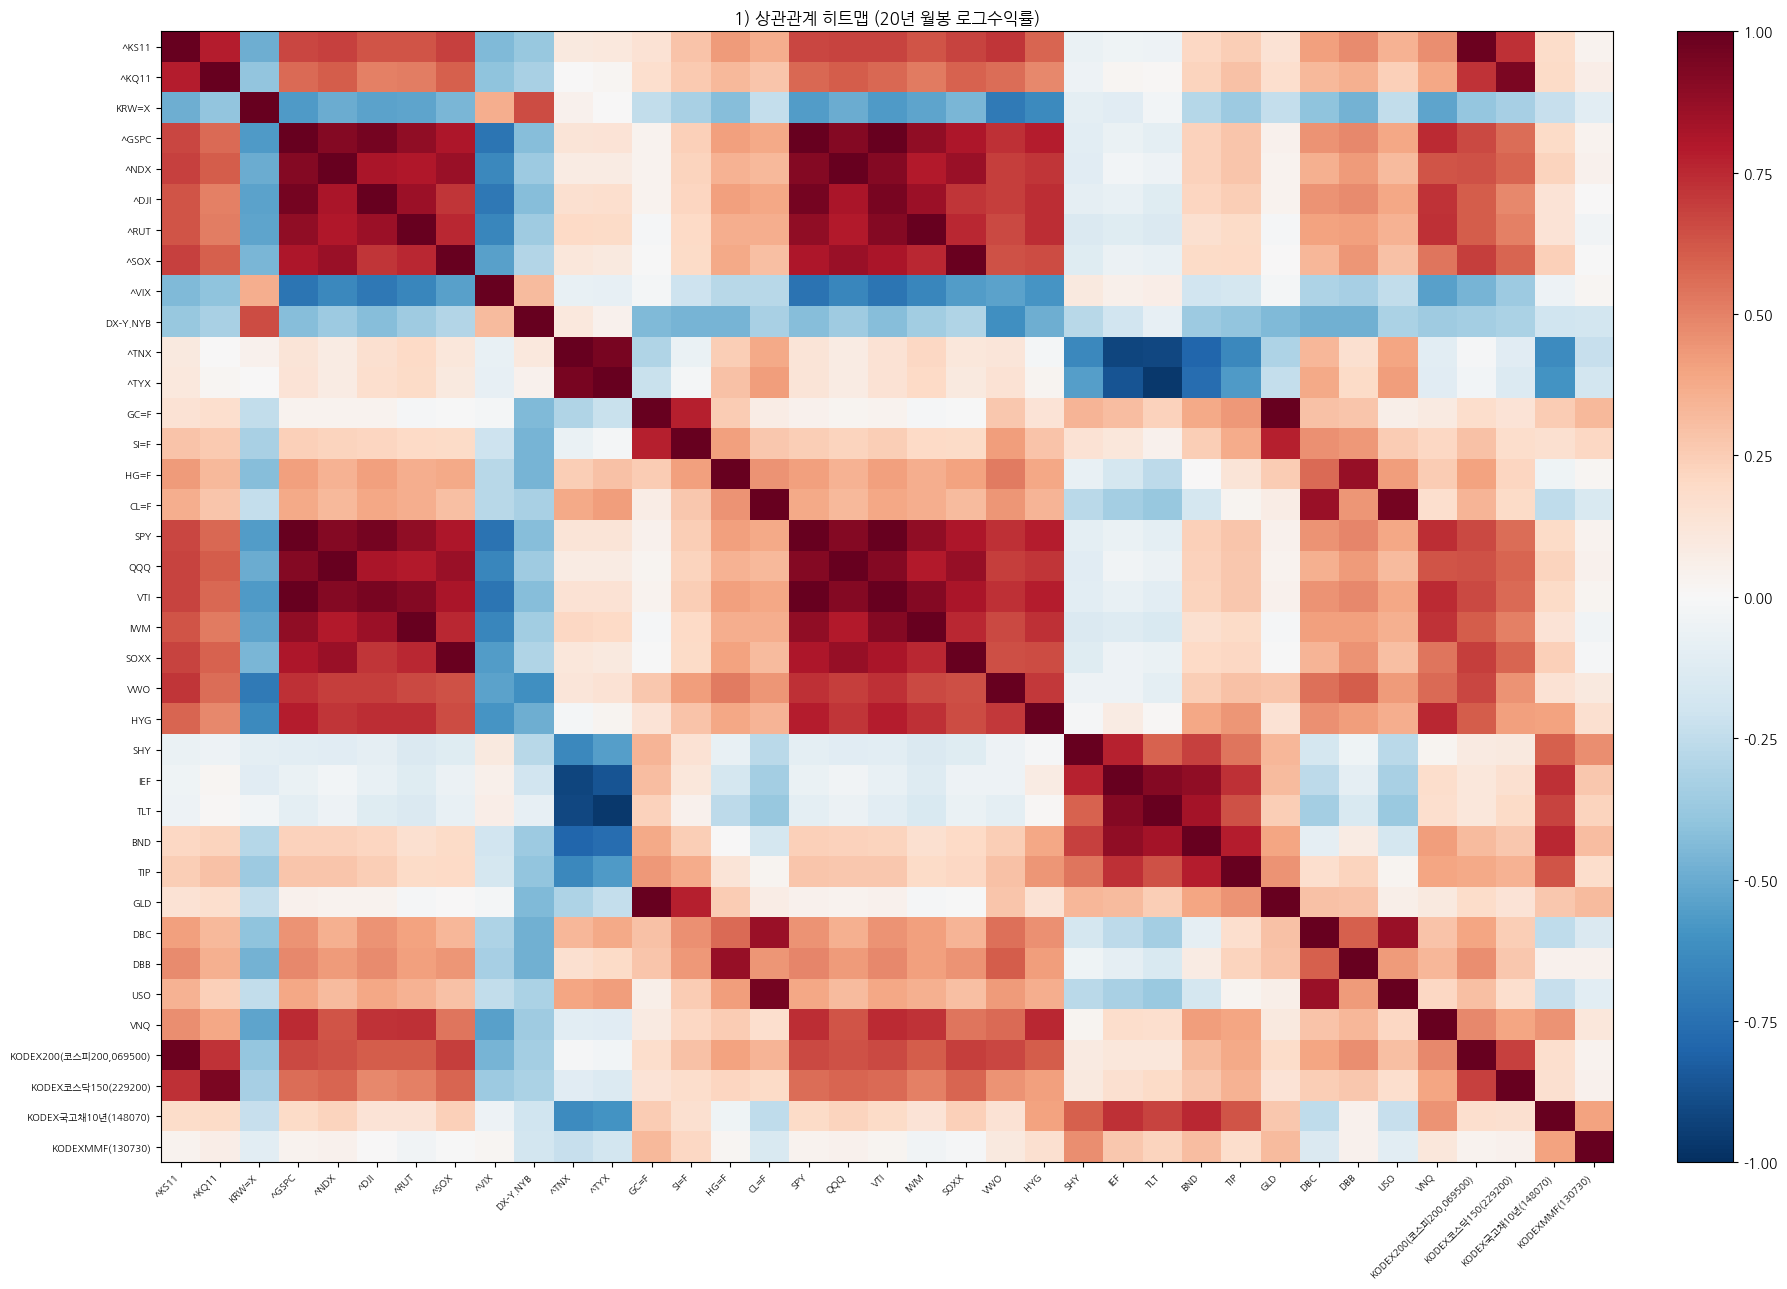

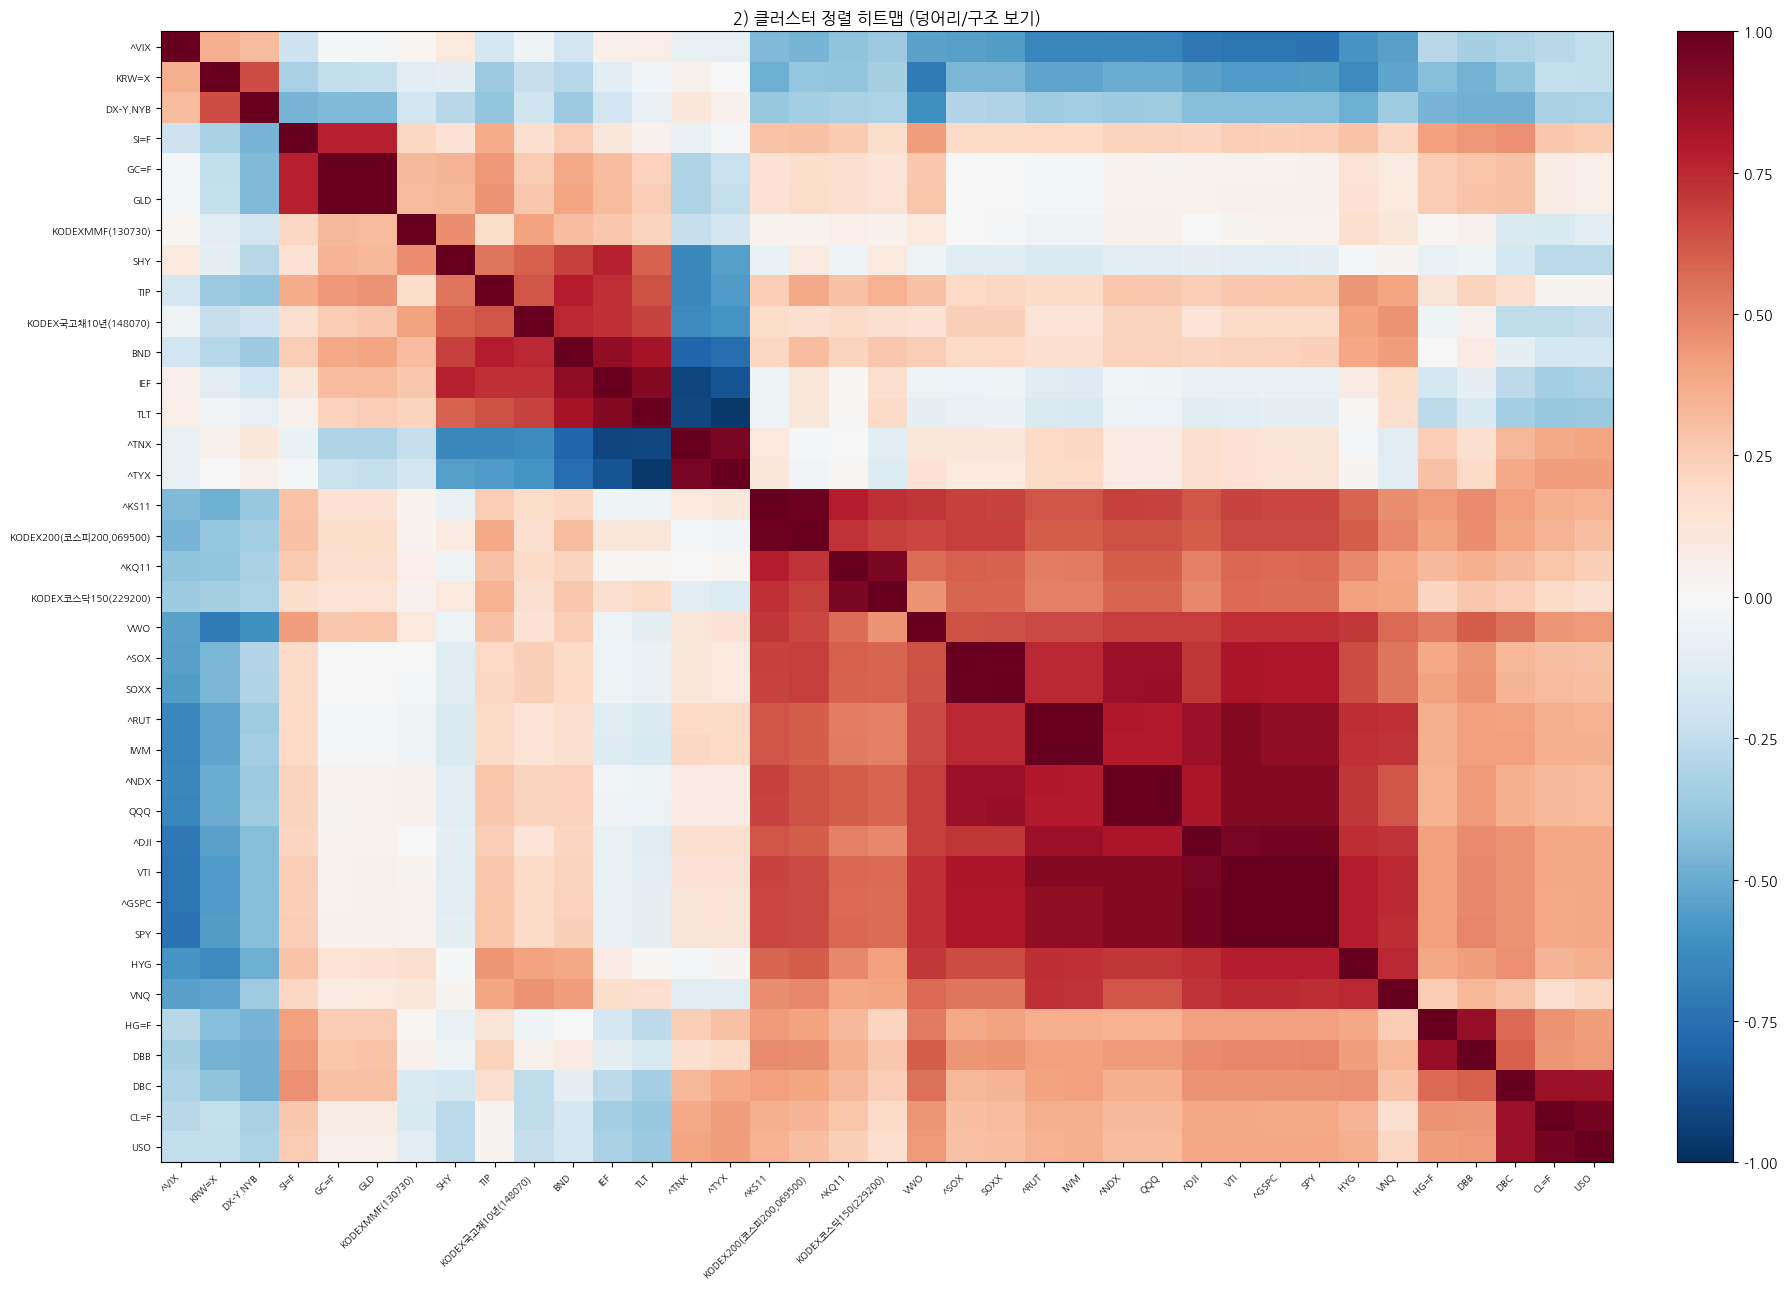

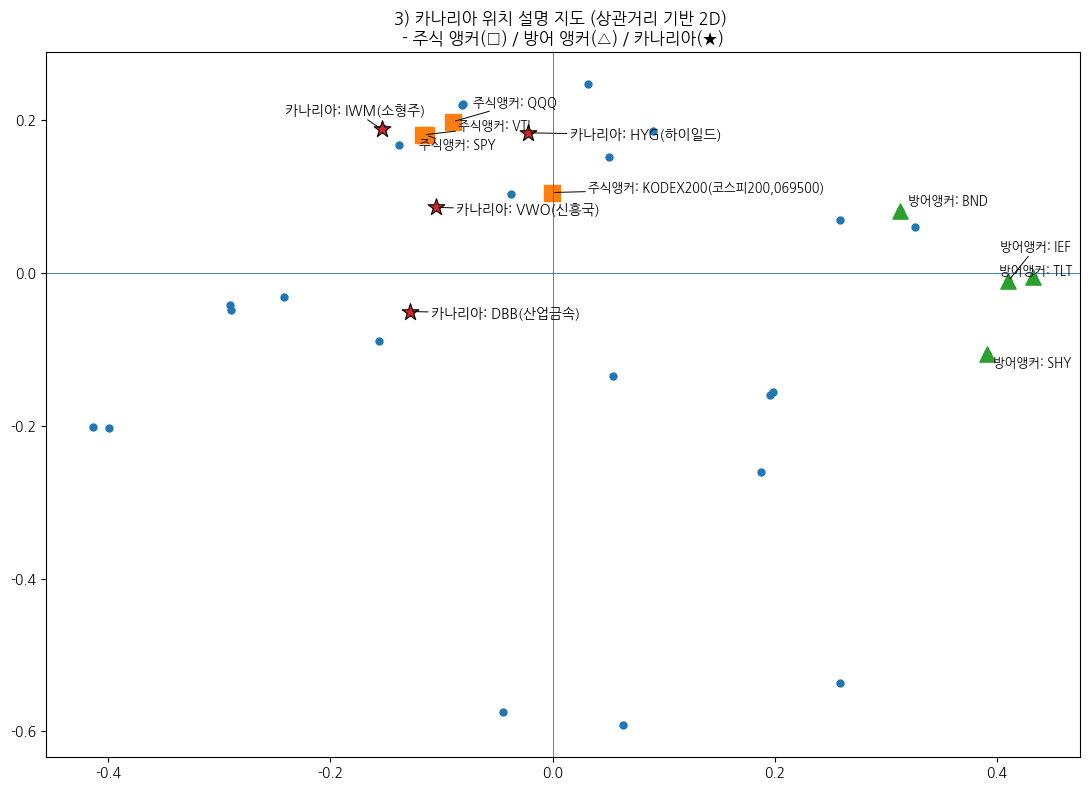


[해석 포인트]
- 카나리아(★)가 '주식앵커(□)' 근처에 있으면: 위험자산 성격(경기/리스크에 민감)
- 그런데 완전히 겹치지 않고 살짝 떨어져 있으면: 주식보다 먼저 흔들릴 가능성이 있어 '경보'로 유리
- 방어앵커(△)와 멀면: 위험/방어 축이 잘 분리된 것(DAA 구조가 깔끔)


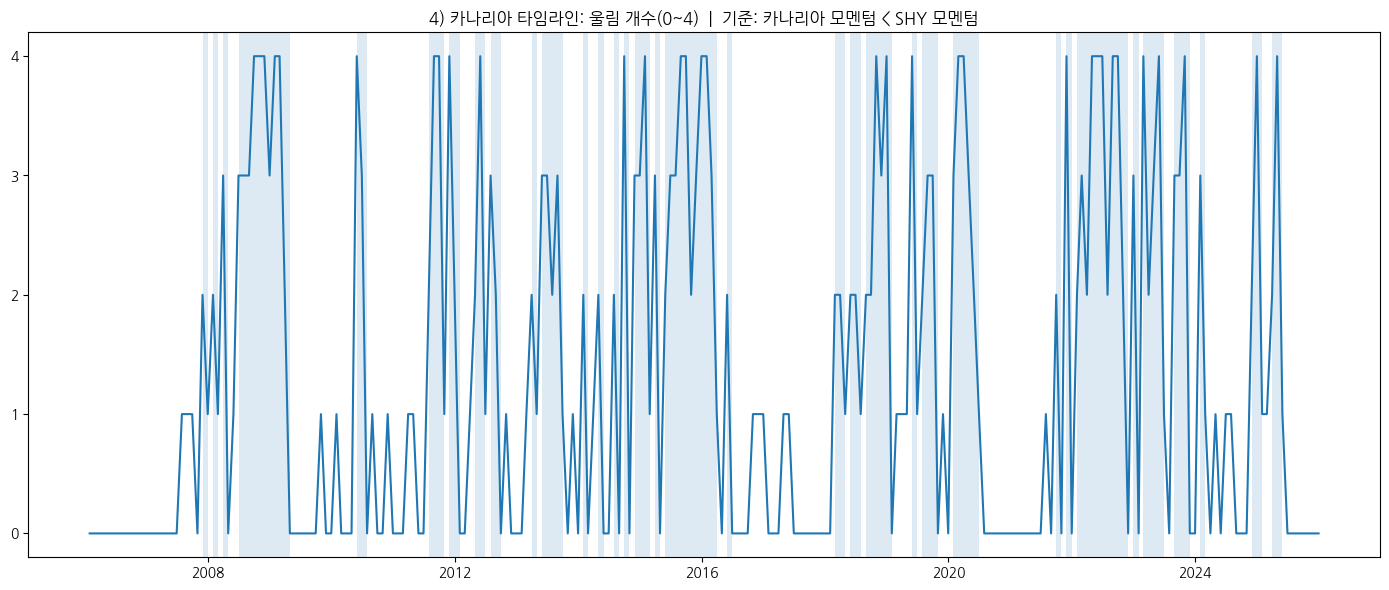

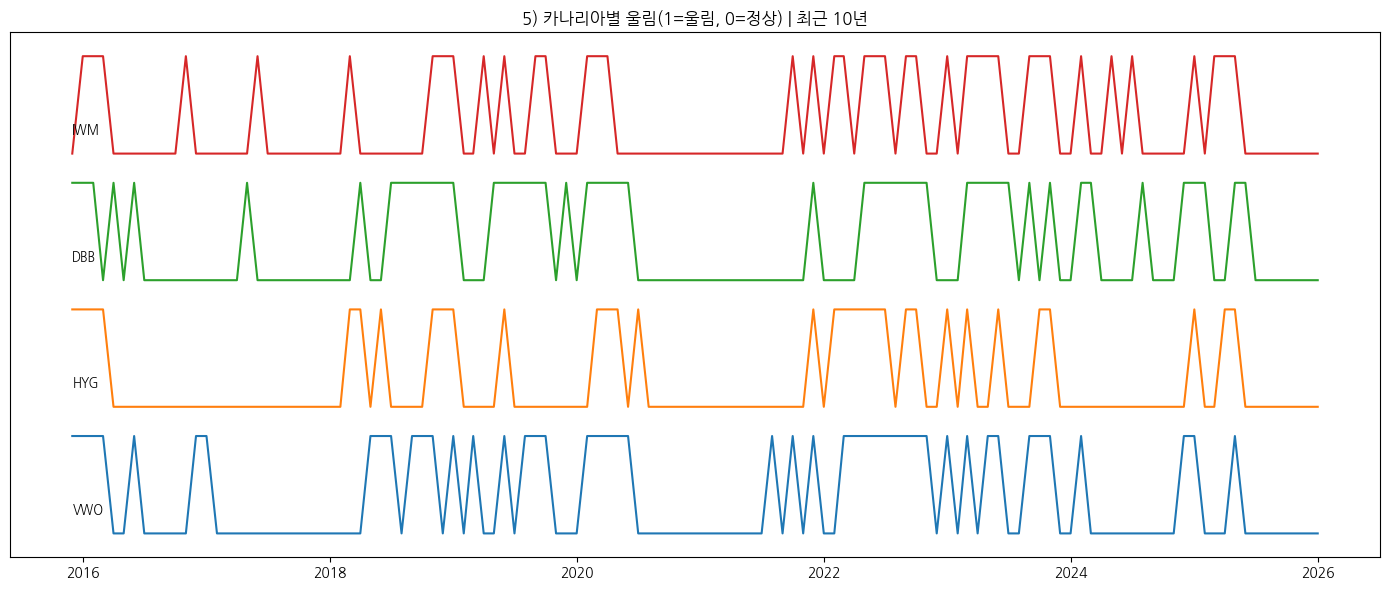


【결론(히트맵 + 카나리아 위치 + 타임라인)】
1) 히트맵에서 '주식 덩어리'와 '채권/현금 덩어리'가 분리되면, DAA 구조가 잘 먹는 환경입니다.
2) 카나리아(신흥국/하이일드/산업금속/소형주)는 주식에 가깝지만 완전히 붙지 않는 위치일수록 '경보' 역할이 좋아집니다.
3) 타임라인에서 2-of-4 음영 구간이 많았던 시기는 리스크오프가 자주 필요했던 국면입니다.
4) 실제 운용은: (2-of-4 울림) => 방어자산으로 이동, (미울림) => 공격자산 중 모멘텀 상위로 운용합니다.


In [4]:
# =========================================================
# [Colab 올인원] 20년 월봉(Log Return) 히트맵 + "카나리아 위치(그림)" + "카나리아 타임라인"
# - 기간: 2006-01-01 ~ 2025-12-31
# - 월봉(M, 월말) / 로그수익률
# - 히트맵: 전체 구조(덩어리) 확인
# - 카나리아 위치 설명 그림: 상관거리 기반 2D 맵(MDS)로 "주식-채권 사이" 위치를 시각화
# - 타임라인: DAA 방식(카나리아 4개) 2-of-4 울림 + 각 카나리아 상태
# - 코스피200: KODEX200(069500) 포함
# =========================================================

!pip -q install yfinance finance-datareader pandas numpy matplotlib scipy scikit-learn openpyxl adjustText

# 한글 폰트 설치 및 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import FinanceDataReader as fdr

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

from sklearn.manifold import MDS
from adjustText import adjust_text

import matplotlib.font_manager as fm # Import font_manager

# Matplotlib 폰트 설정 (한글 깨짐 방지)
# 폰트 경로 찾기 및 설정
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    fm.fontManager.addfont(font_file)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

# -----------------------------
# 0) 설정
# -----------------------------
START = "2006-01-01"
END   = "2025-12-31"
RESAMPLE = "M"

WINSORIZE = True
WQ_LOW, WQ_HIGH = 0.01, 0.99

MIN_MONTHS = 12 * 8
MIN_CORR_PERIODS = 36

# DAA(카나리아 타임라인) 파라미터
MOM_WINDOWS = [1, 3, 6, 12]
MOM_WEIGHTS = [12, 4, 2, 1]
CANARY_RULE_K = 2  # 2-of-4

# -----------------------------
# 1) 유니버스 (구조분석용 + 편입가능 + 카나리아/방어)
# -----------------------------
# 구조분석(지수/선물/현물) - Yahoo
ANALYSIS = {
    "한국_코스피(^KS11)": "^KS11",
    "한국_코스닥(^KQ11)": "^KQ11",
    "원달러환율(KRW=X)": "KRW=X",

    "미국_S&P500(^GSPC)": "^GSPC",
    "미국_나스닥100(^NDX)": "^NDX",
    "미국_다우(^DJI)": "^DJI",
    "미국_러셀2000(^RUT)": "^RUT",

    "미국_필라델피아반도체(^SOX)": "^SOX",
    "변동성_VIX(^VIX)": "^VIX",

    "달러인덱스(DX-Y.NYB)": "DX-Y.NYB",

    "미국10년금리(^TNX)": "^TNX",
    "미국30년금리(^TYX)": "^TYX",

    "금_선물(GC=F)": "GC=F",
    "은_선물(SI=F)": "SI=F",
    "구리_선물(HG=F)": "HG=F",
    "원유_WTI선물(CL=F)": "CL=F",
}

# 편입가능 ETF(미국) - Yahoo
INV_US = {
    "SPY(S&P500)": "SPY",
    "QQQ(Nasdaq100)": "QQQ",
    "VTI(미국전체)": "VTI",
    "IWM(소형주)": "IWM",
    "SOXX(반도체ETF)": "SOXX",

    "VWO(신흥국)": "VWO",
    "HYG(하이일드)": "HYG",

    "SHY(초단기국채)": "SHY",
    "IEF(중기국채)": "IEF",
    "TLT(장기국채)": "TLT",
    "BND(미국종합채권)": "BND",
    "TIP(물가연동채)": "TIP",

    "GLD(금ETF)": "GLD",
    "DBC(원자재종합)": "DBC",
    "DBB(산업금속)": "DBB",
    "USO(원유)": "USO",
    "VNQ(리츠)": "VNQ",
}

# 편입가능 ETF(한국) - FDR
INV_KR = {
    "KODEX200(코스피200,069500)": ("FDR", "069500"),
    "KODEX코스닥150(229200)": ("FDR", "229200"),
    "KODEX국고채10년(148070)": ("FDR", "148070"),
    "KODEXMMF(130730)": ("FDR", "130730"),
    "ACE금현물(411060)": ("FDR", "411060"),
}

# 카나리아 4개(DAA 방식 고정)
CANARY = {
    "카나리아_VWO(신흥국)": "VWO",
    "카나리아_HYG(하이일드)": "HYG",
    "카나리아_DBB(산업금속)": "DBB",
    "카나리아_IWM(소형주)": "IWM",
}

# “카나리아 위치” 비교용 앵커(주식/방어)
ANCHOR_EQUITY = ["SPY(S&P500)", "QQQ(Nasdaq100)", "VTI(미국전체)", "KODEX200(코스피200,069500)"]
ANCHOR_DEF    = ["SHY(초단기국채)", "IEF(중기국채)", "TLT(장기국채)", "BND(미국종합채권)"]

# -----------------------------
# 2) 데이터 로더
# -----------------------------
def fetch_yahoo_close(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if df is None or len(df) == 0 or "Close" not in df.columns:
        return None
    s = df["Close"].dropna()
    return None if s.empty else s

def fetch_fdr_close(code, start, end):
    try:
        df = fdr.DataReader(code, start, end)
        if df is None or len(df) == 0 or "Close" not in df.columns:
            return None
        s = df["Close"].dropna()
        return None if s.empty else s
    except:
        return None

# -----------------------------
# 3) 패널 구성
# -----------------------------
series = []
failed = []

# ANALYSIS
for name, tkr in ANALYSIS.items():
    s = fetch_yahoo_close(tkr, START, END)
    if s is None:
        failed.append(("ANALYSIS", name, tkr))
        continue
    s.name = name
    series.append(s)

# Investable US
for name, tkr in INV_US.items():
    s = fetch_yahoo_close(tkr, START, END)
    if s is None:
        failed.append(("INV_US", name, tkr))
        continue
    s.name = name
    series.append(s)

# Investable KR
for name, spec in INV_KR.items():
    _, code = spec
    s = fetch_fdr_close(code, START, END)
    if s is None:
        failed.append(("INV_KR", name, code))
        continue
    s.name = name
    series.append(s)

prices = pd.concat(series, axis=1).sort_index()
print(f"[로드 성공] {prices.shape[1]}개")
if failed:
    print(f"[로드 실패] {len(failed)}개 - 일부만 표시")
    for x in failed[:20]:
        print(" -", x)

# -----------------------------
# 4) 월봉 + 로그수익률 + 이상치 완화 + 상관
# -----------------------------
prices_m = prices.resample(RESAMPLE).last()
logret = np.log(prices_m / prices_m.shift(1))

valid = logret.count()[logret.count() >= MIN_MONTHS].index
logret_hm = logret[valid].dropna(how="all")

if WINSORIZE:
    lo = logret_hm.quantile(WQ_LOW)
    hi = logret_hm.quantile(WQ_HIGH)
    logret_hm = logret_hm.clip(lower=lo, upper=hi, axis=1)

corr = logret_hm.corr(min_periods=MIN_CORR_PERIODS).dropna(axis=0, how="all").dropna(axis=1, how="all")
print("\n[히트맵 포함 자산 수]", corr.shape[0])
print("[월 표본 범위]", logret_hm.index.min().date(), "~", logret_hm.index.max().date())

# -----------------------------
# 5) 히트맵 + 클러스터 정렬 히트맵
# -----------------------------
def plot_heatmap(corr_df, title):
    plt.figure(figsize=(18, 13))
    ax = plt.gca()
    im = ax.imshow(corr_df.values, vmin=-1, vmax=1, aspect="auto", cmap="RdBu_r")
    ax.set_xticks(np.arange(len(corr_df.columns)))
    ax.set_yticks(np.arange(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(corr_df.index, fontsize=7)
    plt.title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

plot_heatmap(corr, "1) 상관관계 히트맵 (20년 월봉 로그수익률)")

dist = ((1 - corr) / 2).clip(0, 1)
condensed = squareform(dist.values, checks=False)
Z = linkage(condensed, method="average")
order = leaves_list(Z)
corr_sorted = corr.iloc[order, order]
plot_heatmap(corr_sorted, "2) 클러스터 정렬 히트맵 (덩어리/구조 보기)")

# -----------------------------
# 6) 카나리아 위치 설명 그림 (상관거리 -> 2D MDS)
#    - 주식 앵커(Equity) / 방어 앵커(Defense) / 카나리아를 같은 지도에 표시
# -----------------------------
# 지도에 넣을 컬럼(상관행렬에 실제 존재하는 것만)
map_cols = list(corr.columns)

# MDS는 거리행렬이 필요
D = dist.loc[map_cols, map_cols].values

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, n_init=4, max_iter=2000)
xy = mds.fit_transform(D)

coords = pd.DataFrame(xy, index=map_cols, columns=["x", "y"])

# 그룹 정의(존재하는 것만)
canary_names = [k.replace("카나리아_", "") for k in CANARY.keys()]  # 보기 좋게
canary_cols = [k.replace("카나리아_", "") for k in CANARY.keys()]
# 실제 컬럼명은 INV_US의 키(예: "VWO(신흥국)") 형태라서 거기에 맞춰 매핑
def find_col_by_ticker_in_name(tkr):
    for c in coords.index:
        if "(" in c and c.endswith(")") and c.split("(")[0].strip().endswith(tkr) is False:
            pass
    for c in coords.index:
        # "VWO(신흥국)" 처럼 티커가 앞에 있는 경우
        if c.startswith(tkr + "(") or c.endswith("(" + tkr + ")"):
            return c
    # "카나리아_" 접두가 있는 형태는 여기에는 없음(우리는 INV_US로 로드됨)
    for c in coords.index:
        if tkr in c:
            return c
    return None

canary_map = {}
for label, tkr in CANARY.items():
    col = find_col_by_ticker_in_name(tkr)
    if col is not None:
        canary_map[col] = label.replace("카나리아_", "")

equity_cols = []
for t in ["SPY", "QQQ", "VTI"]:
    c = find_col_by_ticker_in_name(t)
    if c is not None:
        equity_cols.append(c)
# 한국 코스피200 ETF
if "KODEX200(코스피200,069500)" in coords.index:
    equity_cols.append("KODEX200(코스피200,069500)")

def_cols = []
for t in ["SHY", "IEF", "TLT", "BND"]:
    c = find_col_by_ticker_in_name(t)
    if c is not None:
        def_cols.append(c)

plt.figure(figsize=(11, 8))
plt.scatter(coords["x"], coords["y"], s=25)

# 앵커 강조
if equity_cols:
    plt.scatter(coords.loc[equity_cols, "x"], coords.loc[equity_cols, "y"], s=120, marker="s")
if def_cols:
    plt.scatter(coords.loc[def_cols, "x"], coords.loc[def_cols, "y"], s=120, marker="^")

# 카나리아 강조
can_cols = list(canary_map.keys())
if can_cols:
    plt.scatter(coords.loc[can_cols, "x"], coords.loc[can_cols, "y"], s=160, marker="*", edgecolor="black", linewidth=0.8)

# 라벨(카나리아 + 앵커만)
texts = []
for c in equity_cols:
    texts.append(plt.text(coords.loc[c, "x"], coords.loc[c, "y"], "주식앵커: " + c, fontsize=9))
for c in def_cols:
    texts.append(plt.text(coords.loc[c, "x"], coords.loc[c, "y"], "방어앵커: " + c, fontsize=9))
for c, nice in canary_map.items():
    texts.append(plt.text(coords.loc[c, "x"], coords.loc[c, "y"], "카나리아: " + nice, fontsize=10))

adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.7))

plt.title("3) 카나리아 위치 설명 지도 (상관거리 기반 2D) \n- 주식 앵커(□) / 방어 앵커(△) / 카나리아(★)")
plt.axhline(0, linewidth=0.6)
plt.axvline(0, linewidth=0.6)
plt.tight_layout()
plt.show()

print("\n[해석 포인트]")
print("- 카나리아(★)가 '주식앵커(□)' 근처에 있으면: 위험자산 성격(경기/리스크에 민감)")
print("- 그런데 완전히 겹치지 않고 살짝 떨어져 있으면: 주식보다 먼저 흔들릴 가능성이 있어 '경보'로 유리")
print("- 방어앵커(△)와 멀면: 위험/방어 축이 잘 분리된 것(DAA 구조가 깔끔)")

# -----------------------------
# 7) DAA 방식 카나리아 타임라인
#    - 모멘텀 점수: (1m*12 + 3m*4 + 6m*2 + 12m*1)
#    - 울림: 카나리아 점수 < SHY 점수 (상대모멘텀, 오경보 감소)
#    - 2-of-4 이상 울리면 "리스크오프"
# -----------------------------
def weighted_momentum(px_m, windows, weights):
    out = None
    for w, wt in zip(windows, weights):
        mom = (px_m / px_m.shift(w)) - 1
        part = mom * wt
        out = part if out is None else (out + part)
    return out

mom = weighted_momentum(prices_m, MOM_WINDOWS, MOM_WEIGHTS)

# 카나리아 컬럼(실제 존재하는 것만)
can_cols_real = []
for _, tkr in CANARY.items():
    c = find_col_by_ticker_in_name(tkr)
    if c is not None and c in mom.columns:
        can_cols_real.append(c)

# SHY 기준
shy_col = find_col_by_ticker_in_name("SHY")
if shy_col is None or shy_col not in mom.columns:
    raise ValueError("SHY(초단기국채) 데이터가 없어서 카나리아 상대모멘텀을 계산할 수 없습니다.")

sig = pd.DataFrame(index=mom.index)
for c in can_cols_real:
    sig[c] = mom[c] < mom[shy_col]

sig["울림개수"] = sig[can_cols_real].sum(axis=1)
sig["울림(2of4)"] = sig["울림개수"] >= CANARY_RULE_K

# 타임라인 그림(전체 기간)
plt.figure(figsize=(14, 6))
plt.plot(sig.index, sig["울림개수"].values)
plt.title("4) 카나리아 타임라인: 울림 개수(0~4)  |  기준: 카나리아 모멘텀 < SHY 모멘텀")
plt.ylim(-0.2, 4.2)
plt.yticks([0,1,2,3,4])

# 2-of-4 구간 음영
on = sig["울림(2of4)"].fillna(False).values
x = sig.index
start = None
for i in range(len(on)):
    if on[i] and start is None:
        start = x[i]
    if (not on[i]) and start is not None:
        plt.axvspan(start, x[i], alpha=0.15)
        start = None
if start is not None:
    plt.axvspan(start, x[-1], alpha=0.15)

plt.tight_layout()
plt.show()

# 카나리아별 ON/OFF(최근 10년만 보기)
tail_years = 10
tail_n = tail_years * 12 + 2
tail = sig.tail(tail_n).copy()

plt.figure(figsize=(14, 6))
y_offset = 0
for c in can_cols_real:
    y = tail[c].astype(int).values + y_offset
    plt.plot(tail.index, y)
    plt.text(tail.index[0], y_offset + 0.2, c, fontsize=9)
    y_offset += 1.3

plt.title("5) 카나리아별 울림(1=울림, 0=정상) | 최근 10년")
plt.yticks([])
plt.tight_layout()
plt.show()

# -----------------------------
# 8) 텍스트 결론(프린트)
# -----------------------------
print("\n" + "="*80)
print("【결론(히트맵 + 카나리아 위치 + 타임라인)】")
print("="*80)
print("1) 히트맵에서 '주식 덩어리'와 '채권/현금 덩어리'가 분리되면, DAA 구조가 잘 먹는 환경입니다.")
print("2) 카나리아(신흥국/하이일드/산업금속/소형주)는 주식에 가깝지만 완전히 붙지 않는 위치일수록 '경보' 역할이 좋아집니다.")
print("3) 타임라인에서 2-of-4 음영 구간이 많았던 시기는 리스크오프가 자주 필요했던 국면입니다.")
print("4) 실제 운용은: (2-of-4 울림) => 방어자산으로 이동, (미울림) => 공격자산 중 모멘텀 상위로 운용합니다.")
print("="*80)


In [5]:
# =========================================================
# [추가] DAA용 카나리아 세트 자동선별 (히트맵/상관행렬 기반)
# - 목표:
#   ① 주식바스켓과 절대상관 낮음(경보 민감도↑)
#   ② 카나리아끼리도 서로 상관 낮음(중복↓)
#   ③ 실무 규칙: BOND/CASH 최소 1개 포함(안전장치)
# - 출력: TOP 세트(3개/4개) 추천
# =========================================================

from itertools import combinations

def make_equity_basket(corr_df):
    # `corr_df.columns`에 실제 존재하는 컬럼 이름을 사용하도록 수정
    prefer = [
        "SPY", # `INV_US`에서 로드된 이름
        "QQQ", # `INV_US`에서 로드된 이름
        "VTI", # `INV_US`에서 로드된 이름
        "KODEX200(코스피200,069500)", # `INV_KR`에서 로드된 이름
        "한국_코스피(^KS11)", # `ANALYSIS`에서 로드된 이름
        "한국_코스닥(^KQ11)", # `ANALYSIS`에서 로드된 이름
        "미국_S&P500(^GSPC)", # `ANALYSIS`에서 로드된 이름
        "미국_나스닥100(^NDX)", # `ANALYSIS`에서 로드된 이름
        "미국_다우(^DJI)", # `ANALYSIS`에서 로드된 이름
        "미국_러셀2000(^RUT)", # `ANALYSIS`에서 로드된 이름
    ]
    basket = [x for x in prefer if x in corr_df.columns]

    if len(basket) == 0:
        # 선호하는 주식 바스켓 자산이 없는 경우, 분류 기준을 활용한 대체 주식 자산 선택
        available_equities = [col for col in corr_df.columns if classify_asset(col) == "EQUITY"]
        if len(available_equities) > 0:
            basket = available_equities[:2] # 최소 2개 선택
        else:
            basket = list(corr_df.columns[:2]) # 정말 없을 때의 최후의 보루
    return basket

def classify_asset(name: str):
    u = name.upper()

    if any(k in u for k in ["VXX","VXZ"]):
        return "VOL"

    if any(k in u for k in ["SHY","IEF","TLT","BND","VCLT","TIP","SCHP","FLOT","BNDX", "국고채"]): # "국고채" 추가
        return "BOND"
    if "MMF" in u or "MMF" in name:
        return "CASH"

    if any(k in u for k in ["GLD","IAU"]) or "금현물" in name:
        return "GOLD"

    if any(k in u for k in ["DBC","DBA","DBB","CPER","USO","UNG","URA","GDX","SLV"]):
        return "COMMOD"

    if any(k in u for k in ["VNQ","REET","IGF"]):
        return "REAL"

    if any(k in u for k in ["SPY","QQQ","DIA","IWM","VUG","VTV","QUAL","USMV","XLP","XLV","XLU","XLE","SOXX","VTI","VEA","VWO","VGK","EWJ"]):
        return "EQUITY"

    return "OTHER"

def canary_candidates_from_corr(corr_df, investable_names, max_abs_corr_to_equity=0.25, exclude_equity_like=True):
    equity_basket = make_equity_basket(corr_df)
    cands = [x for x in corr_df.columns if x in investable_names]

    eq_corr = corr_df.loc[cands, equity_basket].mean(axis=1)
    out = pd.DataFrame({
        "corr_to_equity": eq_corr,
        "abs_corr_to_equity": eq_corr.abs(),
        "cls": [classify_asset(x) for x in cands]
    }).dropna()

    out = out[out["abs_corr_to_equity"] <= max_abs_corr_to_equity].copy()
    if exclude_equity_like:
        out = out[out["cls"] != "EQUITY"].copy()

    out = out.sort_values(["abs_corr_to_equity"])
    return equity_basket, out

def score_canary_set(corr_df, assets, equity_basket, w1=0.7, w2=0.3):
    # (A) 주식바스켓과 평균 절대상관 (낮을수록 좋음)
    eq = corr_df.loc[assets, equity_basket].mean(axis=1).abs().mean()

    # (B) 카나리아끼리 평균 절대상관 (낮을수록 좋음)
    sub = corr_df.loc[assets, assets].abs()
    iu = np.triu_indices(len(assets), k=1)
    pair = sub.values[iu].mean() if len(iu[0]) > 0 else 0.0

    score = w1 * eq + w2 * pair
    return float(score), float(eq), float(pair)

def pass_rules(assets):
    cls = [classify_asset(x) for x in assets]
    # 실무: 방어축(BOND/CASH) 최소 1개
    has_def = ("BOND" in cls) or ("CASH" in cls)
    # VOL 너무 많으면 오경보/장기부적합 → 최대 1개
    vol_ok = (sum(c == "VOL" for c in cls) <= 1)
    return has_def and vol_ok

def find_best_canary_sets(corr_df, investable_names, set_sizes=(3,4), top_n=10,
                          max_abs_corr_to_equity=0.25, exclude_equity_like=True,
                          apply_rules=True, w1=0.7, w2=0.3):

    equity_basket, cand_table = canary_candidates_from_corr(
        corr_df, investable_names,
        max_abs_corr_to_equity=max_abs_corr_to_equity,
        exclude_equity_like=exclude_equity_like
    )
    cands = list(cand_table.index)

    rows = []
    for k in set_sizes:
        for comb in combinations(cands, k):
            comb = list(comb)
            if apply_rules and (not pass_rules(comb)):
                continue
            score, eq_mean, pair_mean = score_canary_set(corr_df, comb, equity_basket, w1=w1, w2=w2)
            rows.append({
                "k": k,
                "score": score,
                "mean_abs_corr_to_equity": eq_mean,
                "mean_abs_corr_between_canaries": pair_mean,
                "set": comb,
                "classes": [classify_asset(x) for x in comb]
            })

    # Handle case where no rows are generated
    if not rows:
        res = pd.DataFrame(columns=["k", "score", "mean_abs_corr_to_equity",
                                    "mean_abs_corr_between_canaries", "set", "classes"])
    else:
        res = pd.DataFrame(rows).sort_values(["k","score"]).groupby("k").head(top_n).reset_index(drop=True)

    print("[주식 바스켓(기준)]", equity_basket)
    print(f"[카나리아 후보조건] abs_corr_to_equity <= {max_abs_corr_to_equity} | exclude_equity_like={exclude_equity_like}")
    print(f"[세트 점수] score = {w1}*equity + {w2}*pair | rules={apply_rules}")
    return res, cand_table

# ---- 실행 ----
investable_names = list(INV_US.keys()) + list(INV_KR.keys())

# 히트맵 정렬된 상관(추천) or 원본 상관
corr_for_canary = corr_sorted.copy() # Assuming `corr_sorted` is the sorted correlation matrix from previous cells

best_canary_sets, canary_candidates = find_best_canary_sets(
    corr_df=corr_for_canary,
    investable_names=investable_names,
    set_sizes=(3,4),
    top_n=10,
    max_abs_corr_to_equity=0.5,   # 더 엄격: 0.20 -> 완화
    exclude_equity_like=True,
    apply_rules=True,
    w1=0.7, w2=0.3
)

print("\n[DAA 카나리아 세트 추천 TOP]")
display(best_canary_sets)

print("\n[카나리아 후보(필터 통과) 상위 30]")
display(canary_candidates.head(30))

[주식 바스켓(기준)] ['SPY', 'QQQ', 'VTI', 'KODEX200(코스피200,069500)']
[카나리아 후보조건] abs_corr_to_equity <= 0.5 | exclude_equity_like=True
[세트 점수] score = 0.7*equity + 0.3*pair | rules=True

[DAA 카나리아 세트 추천 TOP]


,k,score,mean_abs_corr_to_equity,mean_abs_corr_between_canaries,set,classes



[카나리아 후보(필터 통과) 상위 30]


,corr_to_equity,abs_corr_to_equity,cls
KODEXMMF(130730),0.034723,0.034723,CASH
KODEX국고채10년(148070),0.193425,0.193425,BOND
